Частина третя: Аналіз датасет c Kaggle.com

In [ ]:
У цій частині домашньої роботи ми ще більше заглибимося в бібліотеку pandas та розглянемо просунутіші функції.
Для цієї вправи ми використовуємо дані за Топ-50 рейтингом книг, що найбільше продаються на Amazon за 11 років (з 2009 по 2019). 
Датасет знаходиться у відкритому доступі на Kaggle.com. 
Завантажте файл csv за посиланням і перемістіть його в ту саму директорію, де знаходиться ваш робочий ноутбук (для зручності). 
Після цього переходьте до завдання
Для виконання цієї частини домашнього завдання потрібно буде не тільки написати код, а й відповісти на супутні запитання. 
Там, де ви побачите виділений жирним шрифтом напис відповідь: потрібно буде вставити питання у файл і відповідь на нього.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

Прочитайте csv файл (використовуйте функцію read_csv)

In [19]:
df = pd.read_csv("bestsellers_with_categories.csv")

Виведіть перші п'ять рядків (використовується функція head)

In [20]:
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


Виведіть розміри датасету (використовуйте атрибут shape)

In [21]:
df.shape

(550, 7)

In [ ]:
Питання: Про скільки книг зберігає дані датасет?

In [ ]:
Відповідь: 550

Для кожної з книг доступні 7 змінних (колонок). Давайте розглянемо їх детальніше:

Name - назва книги

Author - автор

User Rating - рейтинг (за 5-бальною шкалою)

Reviews - кількість відгуків

Price - ціна (у доларах станом на 2020 рік)

Year - рік, коли книга потрапила до рейтингу Топ-50

Genre - жанр

Для спрощення подальшої роботи давайте трохи підправимо назви змінних. Як бачите, тут усі назви починаються з великої літери, а одна - навіть містить пробіл. Це дуже небажано і може бути досить незручним. Давайте змінимо регістр на малий, а пробіл замінимо на нижнє підкреслення (snake_style). А заразом і вивчимо корисний атрибут датафрейму: columns (можна просто присвоїти список нових імен цьому атрибуту)

In [22]:
df.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']

Первинне дослідження даних

Перевірте, чи у всіх рядків вистачає даних: виведіть кількість пропусків (na) у кожному зі стовпців (використовуйте функції isna та sum)

In [23]:
df.isna().sum()

name           0
author         0
user_rating    0
reviews        0
price          0
year           0
genre          0
dtype: int64

Питання: Чи є в якихось змінних пропуски? (Так / ні)

Відповідь: ні

Перевірте, які є унікальні значення в колонці genre (використовуйте функцію unique)

In [24]:
df["genre"].unique()

array(['Non Fiction', 'Fiction'], dtype=object)

Питання: Які є унікальні жанри?

Відповідь: 'Non Fiction', 'Fiction'

Тепер подивіться на розподіл цін: побудуйте діаграму (використовуйте kind='hist')

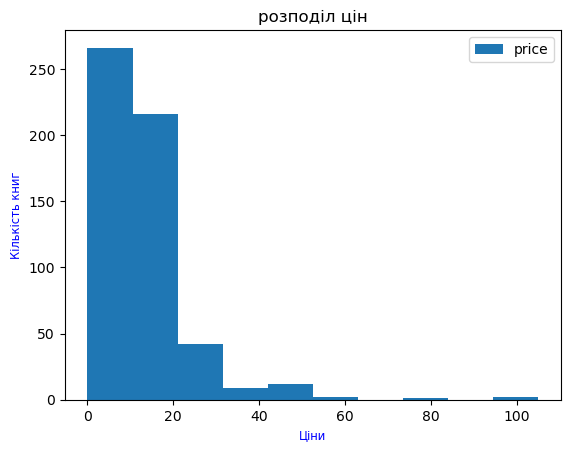

In [39]:
df.plot(y="price",kind='hist')
plt.title("розподіл цін")
plt.xlabel("Ціни",fontsize="small",color="blue")
plt.ylabel("Кількість книг",fontsize="small",color="blue")
plt.show()

Визначте, яка ціна у нас максимальна, мінімальна, середня, медіанна (використовуйте функції max, min, mean, median)

In [44]:
## fastest approach
# df.describe()
max_price = df["price"].max()
min_price = df["price"].min()
mean_price = df["price"].mean()
median_price = df["price"].median()
print("максимальна ціна: ", max_price)
print("мінімальна ціна: ", min_price)
print("середня ціна: ", mean_price)
print("медіанна ціна: ", median_price)

максимальна ціна:  105
мінімальна ціна:  0
середня ціна:  13.1
медіанна ціна:  11.0


Питання: максимальна ціна

Відповідь: 105

Питання: мінімальна ціна

Відповідь: 0

Питання: середня ціна

Відповідь: 13.1

Питання: медіанна ціна

Відповідь: 11

Пошук та сортування даних

Питання: Який рейтинг у датасеті найвищий? 

In [55]:
max_rating = df["user_rating"].max()
print("найвищий рейтинг у датасеті: ", max_rating)

найвищий рейтинг у датасеті:  4.9


Відповідь: 4.9

Питання: Скільки книг мають такий рейтинг?

In [72]:
df[df["user_rating"] == max_rating].shape[0]
#alternative
# df[df["user_rating"] == max_rating].count()

52

Відповідь: 52

Питання: Яка книга має найбільше відгуків?

In [84]:
max_reviews = df["reviews"].max()
# print('книга, що має найбільше відгуків: ',max_reviews)
df.loc[df["reviews"] == max_reviews, ["name", "reviews"]]

,name,reviews
534,Where the Crawdads Sing,87841


Відповідь: Книга «Where the Crawdads Sing» з 87 841 відгуком має найбільшу кількість відгуків 

Питання: З тих книг, що потрапили до Топ-50 у 2015 році, яка книга найдорожча (можна використати проміжний датафрейм)?

In [106]:
df_2015_top = (df[df["year"] == 2015].sort_values(by="user_rating", ascending=False).head(50)[["name", "user_rating", "price"]])
max_price_top_book = df_2015_top["price"].max()
df_2015_top.loc[df_2015_top["price"] == max_price_top_book, ["name", "price"]]

,name,price
277,Publication Manual of the American Psychologic...,46


Відповідь: книга Publication Manual of the American Psychological Association, 6th Edition є найдорожчою книгою (вартістю 46), що потрапила до Топ-50 у 2015 році

Питання: Скільки книг жанру Fiction потрапили до Топ-50 у 2010 році (використовуйте &)?

In [129]:
top_50 = df[df["year"] == 2010].sort_values(by="user_rating", ascending=False).head(50)[["name", "genre"]]
fiction_genre = top_50[top_50["genre"] == "Fiction"].shape[0]
print(fiction_genre)

20


Відповідь: 20 книг жанру Fiction потрапили до Топ-50 у 2010 році 

Питання: Скільки книг з рейтингом 4.9 потрапило до рейтингу у 2010 та 2011 роках (використовуйте | або функцію isin)? 

In [145]:
# df[(df["user_rating"] == 4.9) & ((df["year"] == 2010)| (df["year"] == 2011))].shape[0]
df[(df["user_rating"] == 4.9) & (df["year"].isin([2010,2011]))].shape[0]

1

Відповідь: 1 книга з рейтингом 4.9 потрапила до рейтингу у 2010 та 2011 роках

І насамкінець, давайте відсортуємо за зростанням ціни всі книги, які потрапили до рейтингу в 2015 році і коштують дешевше за 8 доларів (використовуйте функцію sort_values).

In [154]:
# df[(df["year"] == 2015) & (df["price"] < 8)].sort_values(by="price",ascending=True)
result = df[(df["year"] == 2015) & (df["price"] < 8)].sort_values(by="price",ascending=True)
result.iloc[-1]["name"]

'Old School (Diary of a Wimpy Kid #10)'

Питання: Яка книга остання у відсортованому списку?

Відповідь: Old School (Diary of a Wimpy Kid #10) остання книга у відсортованому списку

Агрегування даних та з'єднання таблиць

Остання секція цього домашнього завдання включає просунутіші функції. Але не хвилюйтеся, pandas робить усі операції простими та зрозумілими.

Для початку давайте подивимося на максимальну та мінімальну ціни для кожного з жанрів (використовуйте функції groupby та agg, для підрахунку мінімальних та максимальних значень використовуйте max та min). Не беріть усі стовпці, виберіть тільки потрібні вам

In [181]:
# df.groupby(by=["genre"]).max()
min_max_values = df.groupby("genre")[["genre","price"]].agg(["min","max"])
min_max_values

genre              price     
                     min          max   min  max
genre                                           
Fiction          Fiction      Fiction     0   82
Non Fiction  Non Fiction  Non Fiction     0  105

Питання: Максимальна ціна для жанру Fiction?

Відповідь: 82

Питання: Мінімальна ціна для жанру Fiction?

Відповідь: 0

Питання: Максимальна ціна для жанру Non Fiction?

Відповідь: 105

Питання: Мінімальна ціна для жанру Non Fiction?

Відповідь: 0

Тепер створіть новий датафрейм, який вміщатиме кількість книг для кожного з авторів (використовуйте функції groupby та agg, для підрахунку кількості використовуйте count). Не беріть усі стовпці, виберете тільки потрібні

In [211]:
new_df = df[['author']].copy()
new_df = new_df.groupby('author')['author'].agg(['count']).sort_values(by='count',ascending=False)
new_df = new_df.reset_index()

Питання: Якої розмірності вийшла таблиця?

In [212]:
new_df.shape

(248, 2)

Відповідь:(248, 2)

Питання: Який автор має найбільше книг?

In [215]:
new_df.iloc[0]["author"]

'Jeff Kinney'

Відповідь: Jeff Kinney

In [ ]:
Питання: Скільки книг цього автора?

In [216]:
int(new_df.iloc[0]["count"])

12

Відповідь: 12

Тепер створіть другий датафрейм, який буде вміщати середній рейтинг для кожного автора (використовуйте функції groupby та agg, для підрахунку середнього значення використовуйте mean). Не беріть усі стовпці, виберете тільки потрібні

In [237]:
# second_df = df[["author","user_rating"]].copy()
# grouped_second_df = second_df.groupby("author")
# user_rating_av = grouped_second_df["user_rating"].mean()

second_df = df[["author","user_rating"]].copy()
user_rating_av = second_df.groupby("author")[['user_rating']].agg('mean').sort_values(by='user_rating', ascending=False)
user_rating_av = user_rating_av.reset_index()
user_rating_av

,author,user_rating
0,Patrick Thorpe,4.9
1,Lin-Manuel Miranda,4.9
2,Chip Gaines,4.9
3,Sherri Duskey Rinker,4.9
4,Nathan W. Pyle,4.9
...,...,...
243,Paula Hawkins,4.1
244,Muriel Barbery,4.0
245,Gillian Flynn,4.0
246,Gallup,4.0


Питання: У якого автора середній рейтинг мінімальний?

In [238]:
user_rating_av.iloc[-1]["author"]

'Donna Tartt'

Відповідь: Donna Tartt

Питання: Який у цього автора середній рейтинг?

In [240]:
float(user_rating_av.iloc[-1]["user_rating"])

3.9

Відповідь: 3.9

З'єднайте останні два датафрейми так, щоб для кожного автора було видно кількість книг та середній рейтинг (Використовуйте функцію concat з параметром axis=1). Збережіть результат у змінну

In [249]:
# united_df = pd.merge(new_df,user_rating_av,on="author")
new_df = new_df.set_index("author")
user_rating_av = user_rating_av.set_index("author")
united_df = pd.concat([new_df,user_rating_av],axis=1)
united_df

,count,user_rating
author,,
Jeff Kinney,12,4.800000
Gary Chapman,11,4.736364
Suzanne Collins,11,4.663636
Rick Riordan,11,4.772727
American Psychological Association,10,4.500000
...,...,...
David Grann,1,4.600000
Larry Schweikart,1,4.600000
David McCullough,1,4.700000


Відсортуйте датафрейм за зростаючою кількістю книг та зростаючим рейтингом (використовуйте функцію sort_values)

In [250]:
result = united_df.sort_values(by=["count","user_rating"],ascending=[True,True])
result

,count,user_rating
author,,
Muriel Barbery,1,4.000000
Pierre Dukan,1,4.100000
Chris Cleave,1,4.100000
Ian K. Smith M.D.,1,4.100000
Rob Bell,1,4.200000
...,...,...
American Psychological Association,10,4.500000
Suzanne Collins,11,4.663636
Gary Chapman,11,4.736364


Питання: Який автор перший у списку?

In [254]:
result.iloc[0].name

'Muriel Barbery'

Відповідь: Muriel Barbery